In [4]:
class CampusNavigationSolver:
    def __init__(self, locations, actions, transitions, sensor_data):
        self.locations = locations
        self.actions = actions
        self.transitions = transitions
        self.sensor_data = sensor_data

    def get_next_belief(self, current_belief, action, observation):
        # Predict: Move from all current possible spots
        predicted = {self.transitions.get((loc, action)) for loc in current_belief}
        predicted.discard(None)
        
        # Filter: Only keep spots that match what we currently see (observation)
        new_belief = {loc for loc in predicted if self.sensor_data.get(loc) == observation}
        return frozenset(new_belief)

    def find_path(self, current_belief, goal, path=None, visited=None):
        if path is None: path = []
        if visited is None: visited = set()

        # SUCCESS: If all possible locations in our belief are the goal
        if current_belief and all(loc == goal for loc in current_belief):
            return path

        visited.add(current_belief)

        for action in self.actions:
            # Predict all possible sensor readings we might get after this action
            possible_next_states = {self.transitions.get((loc, action)) for loc in current_belief}
            possible_observations = {self.sensor_data.get(loc) for loc in possible_next_states if loc}

            for obs in possible_observations:
                next_belief = self.get_next_belief(current_belief, action, obs)
                
                if next_belief and next_belief not in visited:
                    result = self.find_path(next_belief, goal, path + [(action, obs)], visited)
                    if result:
                        return result
        return None

# --- Campus Configuration ---
locations = ["Gate", "Library", "Cafe", "Lab"]
actions = ["North", "South"]

# If we go North from Gate, we reach Library, etc.
transitions = {
    ("Gate", "North"): "Library", ("Library", "North"): "Cafe", ("Cafe", "North"): "Lab",
    ("Lab", "South"): "Cafe", ("Cafe", "South"): "Library", ("Library", "South"): "Gate"
}

# Sensors: Gate, Lab, library both look like "Modern Buildings" (Partial Observability)
sensors = {"Gate": "Modern", "Library": "Modern", "Cafe": "Glass", "Lab": "Modern"}

# Initial State: We know we see a 'Modern' building, but don't know if it's Gate or Lab
initial_belief = frozenset(["Gate", "Library", "Lab"])

solver = CampusNavigationSolver(locations, actions, transitions, sensors)
plan = solver.find_path(initial_belief, goal="Lab")

print(f"Navigation Plan (Action, Expected Percept): {plan}")


Navigation Plan (Action, Expected Percept): [('North', 'Glass'), ('North', 'Modern')]


In [5]:
class CampusMap:
    def __init__(self):
        # Directed/Undirected graph of the campus
        self.graph = {
            'Main Gate': ['Library', 'Admin'],
            'Library': ['Main Gate', 'Cafe', 'CS Dept'],
            'Admin': ['Main Gate', 'Cafe'],
            'Cafe': ['Library', 'Admin', 'CS Dept'],
            'CS Dept': ['Library', 'Cafe']
        }

class Navigator:
    def __init__(self, campus):
        self.campus = campus
        # Initial Belief State: Equal probability for all locations (total uncertainty)
        nodes = list(campus.graph.keys())
        self.beliefs = {node: 1/len(nodes) for node in nodes}

    def update_belief(self, observed_node):
        """Update probability based on a sensor reading (Observation Model)"""
        for node in self.beliefs:
            # If observation matches node, increase confidence (90%), else decrease
            self.beliefs[node] = 0.9 if node == observed_node else 0.1
        
        # Normalize to ensure sum of probabilities equals 1
        total = sum(self.beliefs.values())
        self.beliefs = {k: v / total for k, v in self.beliefs.items()}

    def get_location(self):
        """Returns the node with the highest probability"""
        return max(self.beliefs, key=self.beliefs.get)

    def find_path_dfs(self, start, goal, visited=None):
        """Classic Recursive DFS for navigation"""
        if visited is None: visited = set()
        if start == goal: return [goal]
        
        visited.add(start)
        for neighbor in self.campus.graph.get(start, []):
            if neighbor not in visited:
                path = self.find_path_dfs(neighbor, goal, visited)
                if path:
                    return [start] + path
        return None

# Simulation
campus = CampusMap()
nav = Navigator(campus)

# 1. Update belief based on a landmark observation (e.g., user sees the Library)
nav.update_belief('Library')
current_loc = nav.get_location()

# 2. Plan path to destination
destination = 'CS Dept'
path = nav.find_path_dfs(current_loc, destination)

print(f"Current Belief State: {nav.beliefs}")
print(f"Likely Location: {current_loc}")
print(f"Navigation Path to {destination}: {' -> '.join(path) if path else 'Path not found'}")


Current Belief State: {'Main Gate': 0.07692307692307693, 'Library': 0.6923076923076923, 'Admin': 0.07692307692307693, 'Cafe': 0.07692307692307693, 'CS Dept': 0.07692307692307693}
Likely Location: Library
Navigation Path to CS Dept: Library -> Main Gate -> Admin -> Cafe -> CS Dept


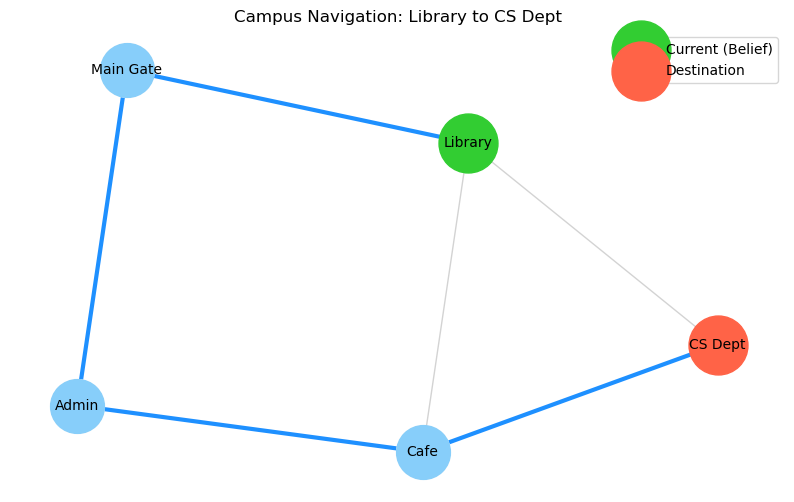

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_navigation(campus, current_loc, destination, path):
    # Create the networkx graph object
    G = nx.Graph()
    for node, neighbors in campus.graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Set layout for nodes
    pos = nx.spring_layout(G, seed=42) 
    plt.figure(figsize=(10, 6))

    # 1. Draw basic infrastructure
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1)
    nx.draw_networkx_nodes(G, pos, node_color='whitesmoke', node_size=1500)
    
    # 2. Highlight the Path found by DFS
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='dodgerblue', width=3)
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='lightskyblue', node_size=1500)

    # 3. Highlight Start (based on Belief State) and Goal
    nx.draw_networkx_nodes(G, pos, nodelist=[current_loc], node_color='limegreen', node_size=1800, label="Current (Belief)")
    nx.draw_networkx_nodes(G, pos, nodelist=[destination], node_color='tomato', node_size=1800, label="Destination")

    # 4. Add Labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

    plt.title(f"Campus Navigation: {current_loc} to {destination}")
    plt.legend(scatterpoints=1)
    plt.axis('off')
    plt.show()

# Execution (assuming variables from the previous block)
visualize_navigation(campus, current_loc, destination, path)


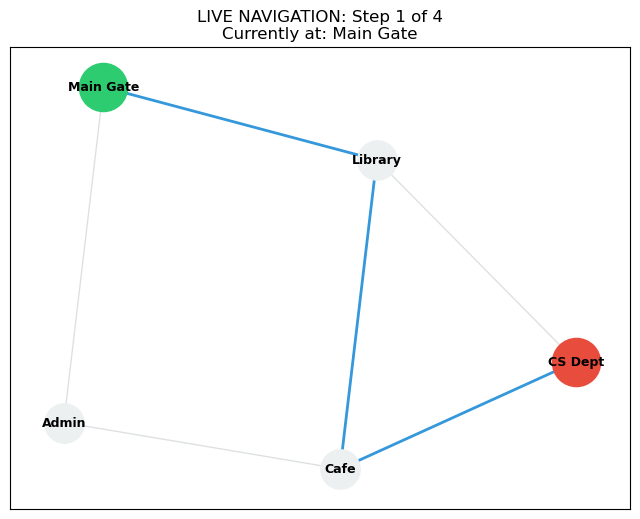

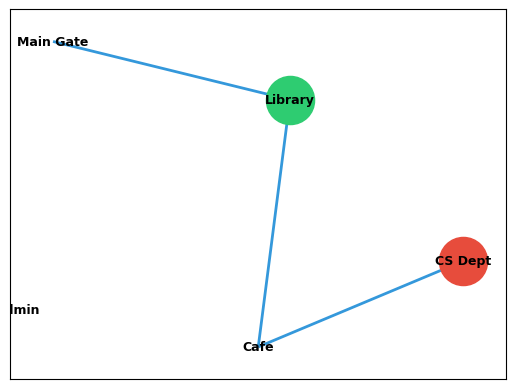

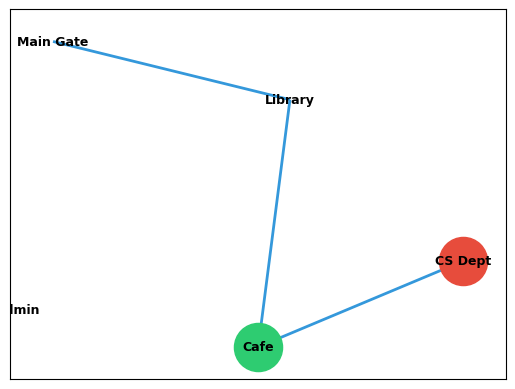

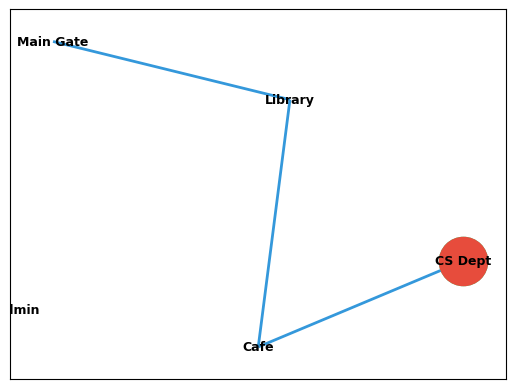

Destination Reached!


In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import time

class LiveCampusNavigator:
    def __init__(self, campus_graph):
        self.graph = campus_graph
        self.beliefs = {node: 1/len(campus_graph) for node in campus_graph}
        
        # Setup visual graph
        self.G = nx.Graph()
        for node, neighbors in self.graph.items():
            for neighbor in neighbors:
                self.G.add_edge(node, neighbor)
        self.pos = nx.spring_layout(self.G, seed=42)

    def update_belief(self, observed_node):
        """Partial Belief: Updates likelihood of current location."""
        for node in self.beliefs:
            self.beliefs[node] = 0.95 if node == observed_node else 0.05
        total = sum(self.beliefs.values())
        self.beliefs = {k: v / total for k, v in self.beliefs.items()}
        return max(self.beliefs, key=self.beliefs.get)

    def dfs_path(self, start, goal, visited=None):
        if visited is None: visited = set()
        if start == goal: return [goal]
        visited.add(start)
        for neighbor in self.graph.get(start, []):
            if neighbor not in visited:
                path = self.dfs_path(neighbor, goal, visited)
                if path: return [start] + path
        return None

    def run_live_nav(self, initial_obs, destination):
        # 1. Determine starting point from initial belief
        current_loc = self.update_belief(initial_obs)
        path = self.dfs_path(current_loc, destination)
        
        if not path:
            print("No path found.")
            return

        plt.ion()  # Turn on interactive mode
        fig, ax = plt.subplots(figsize=(8, 6))

        for i, step_node in enumerate(path):
            # Update belief state at each step (simulating sensor feedback)
            self.update_belief(step_node)
            
            ax.clear()
            # Draw static map
            nx.draw_networkx_edges(self.G, self.pos, ax=ax, edge_color='#bdc3c7', alpha=0.5)
            nx.draw_networkx_nodes(self.G, self.pos, ax=ax, node_color='#ecf0f1', node_size=800)
            
            # Highlight total planned path (breadcrumb trail)
            path_edges = list(zip(path, path[1:]))
            nx.draw_networkx_edges(self.G, self.pos, edgelist=path_edges, edge_color='#3498db', width=2)

            # Highlight Current Position and Destination
            nx.draw_networkx_nodes(self.G, self.pos, nodelist=[step_node], node_color='#2ecc71', node_size=1200)
            nx.draw_networkx_nodes(self.G, self.pos, nodelist=[destination], node_color='#e74c3c', node_size=1200)

            nx.draw_networkx_labels(self.G, self.pos, font_size=9, font_weight='bold')
            
            ax.set_title(f"LIVE NAVIGATION: Step {i+1} of {len(path)}\nCurrently at: {step_node}")
            plt.pause(1.5) # Wait to simulate movement time

        plt.ioff()
        print("Destination Reached!")
        plt.show()

# --- Execution ---
campus_data = {
    'Main Gate': ['Library', 'Admin'],
    'Library': ['Main Gate', 'Cafe', 'CS Dept'],
    'Admin': ['Main Gate', 'Cafe'],
    'Cafe': ['Library', 'Admin', 'CS Dept'],
    'CS Dept': ['Library', 'Cafe']
}

nav = LiveCampusNavigator(campus_data)
# Start at 'Main Gate', go to 'CS Dept'
nav.run_live_nav('Main Gate', 'CS Dept')
